# 🚗 Car Price Prediction with Machine Learning

## Oasis Infobyte Data Science Internship – Task 3

### 🎯 Objective

The objective of this project is to build a Machine Learning regression model that predicts the selling price of a used car based on factors such as its brand, age, mileage, fuel type, transmission, and other relevant features.

### 🛠️ Technologies Used

- Python
- Pandas & NumPy
- Matplotlib & Seaborn
- Scikit-learn
- Jupyter Notebook

### 📌 Project Workflow

Data Collection → Data Cleaning → Feature Engineering → EDA → Model Training → Model Evaluation → Price Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [97]:
# Load the dataset
df = pd.read_csv("D:\OIBSIP\DataScience-Task3-CarPricePrediction\data\car_data.csv")

# Display the first 5 rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [98]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (4340, 8)

Column Names:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

Data Types:
name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [99]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [100]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 763


In [101]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows containing missing values
df = df.dropna()

print("Dataset Shape After Cleaning:", df.shape)
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Dataset Shape After Cleaning: (3577, 8)
Missing Values After Cleaning:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64


In [102]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


name:
['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']

fuel:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission:
['Manual' 'Automatic']

owner:
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [103]:
# Clean and standardize categorical text columns
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()
    
print("Categorical values cleaned successfully!")

Categorical values cleaned successfully!


In [104]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [105]:
df.describe(include="object")

,name,fuel,seller_type,transmission,owner
count,3577,3577,3577,3577,3577
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,54,1800,2832,3265,2218


In [106]:
print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (3577, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [107]:
print("Final Dataset Shape:", df.shape)

df.head()

Final Dataset Shape: (3577, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [108]:
print("Oldest Car Year:", df["year"].min())
print("Newest Car Year:", df["year"].max())

Oldest Car Year: 1992
Newest Car Year: 2020


In [109]:
CURRENT_YEAR = 2026

df["Car_Age"] = CURRENT_YEAR - df["year"]

df[["year", "Car_Age"]].head()

,year,Car_Age
0,2007,19
1,2007,19
2,2012,14
3,2017,9
4,2014,12


In [110]:
print(df["Car_Age"].describe())

count    3577.000000
mean       13.037462
std         4.251759
min         6.000000
25%        10.000000
50%        13.000000
75%        16.000000
max        34.000000
Name: Car_Age, dtype: float64


In [111]:
df["Brand"] = df["name"].str.split().str[0].str.title()

df[["name", "Brand"]].head(10)

,name,Brand
0,Maruti 800 AC,Maruti
1,Maruti Wagon R LXI Minor,Maruti
2,Hyundai Verna 1.6 SX,Hyundai
3,Datsun RediGO T Option,Datsun
4,Honda Amaze VX i-DTEC,Honda
5,Maruti Alto LX BSIII,Maruti
6,Hyundai Xcent 1.2 Kappa S,Hyundai
7,Tata Indigo Grand Petrol,Tata
8,Hyundai Creta 1.6 VTVT S,Hyundai
9,Maruti Celerio Green VXI,Maruti


In [112]:
print("Number of unique brands/models:", df["Brand"].nunique())
print(df["Brand"].value_counts().head(10))

Number of unique brands/models: 29
Brand
Maruti        1072
Hyundai        637
Mahindra       328
Tata           308
Ford           220
Honda          216
Toyota         170
Chevrolet      151
Renault        110
Volkswagen      93
Name: count, dtype: int64


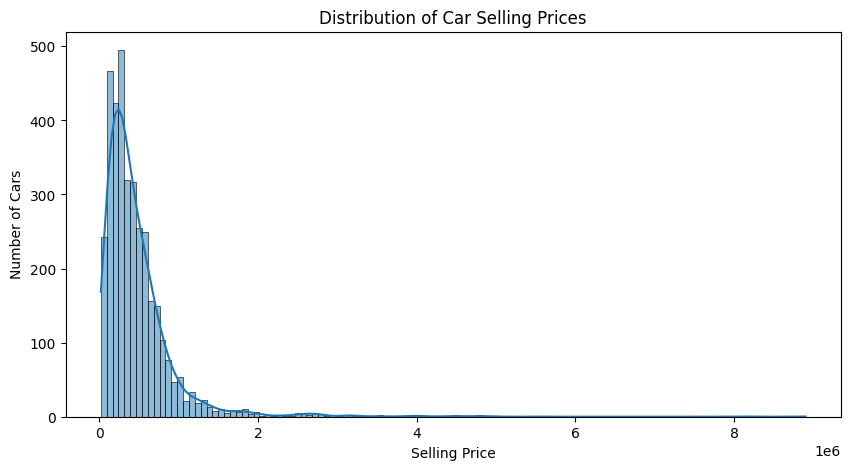

In [113]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="selling_price",
    kde=True
)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

### Observation

The distribution of selling prices shows how used car prices are distributed in the dataset. Most cars are concentrated within a lower price range, while a smaller number of expensive cars create a right-skewed distribution. This indicates the presence of high-value vehicles that may influence regression model performance.

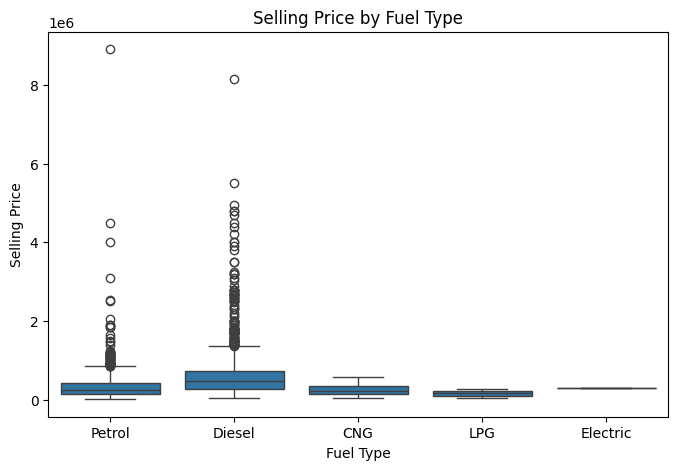

In [114]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="fuel",
    y="selling_price"
)

plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

### Observation

The box plot compares the distribution of selling prices across different fuel types. Differences in median prices and spread indicate that fuel type can influence the resale value of a car.

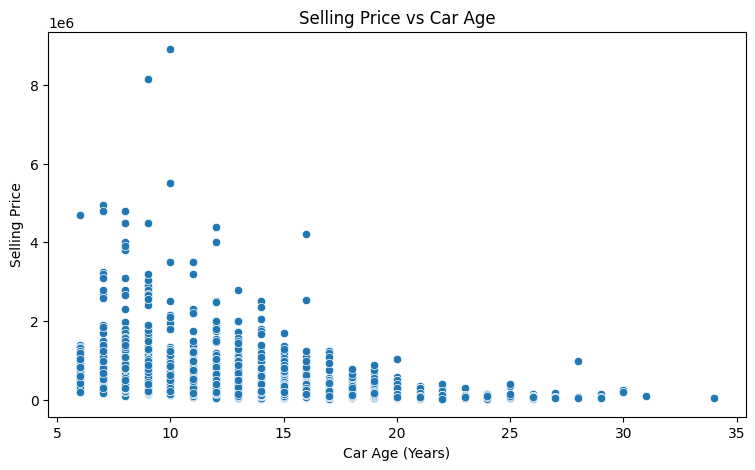

In [115]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="selling_price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price")

plt.show()

### Observation

The scatter plot helps examine the relationship between a car's age and its selling price. Generally, older vehicles tend to have lower resale values because of depreciation, although the relationship can vary depending on the car model and other characteristics.

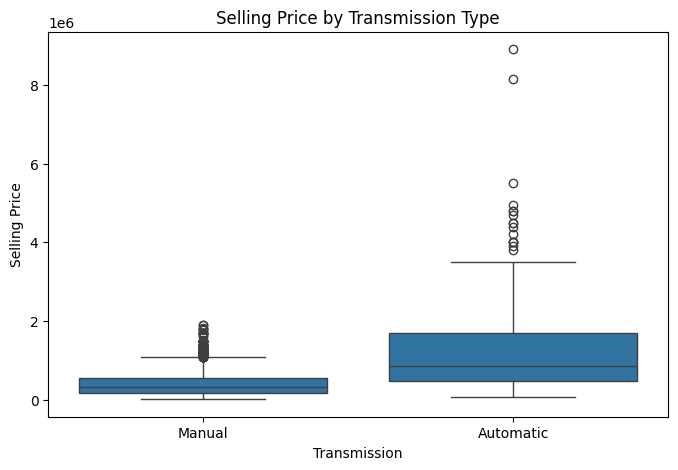

In [116]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")

plt.show()

### Observation

This visualization compares selling prices between manual and automatic transmission vehicles. Any difference in the median and price distribution suggests that transmission type may be an important feature for predicting resale value.

In [117]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (3577, 10)

Columns:
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'Car_Age', 'Brand']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


In [118]:
# Select numerical columns
numerical_df = df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numerical_df.corr()

# Display correlation matrix
correlation_matrix

,year,selling_price,km_driven,Car_Age
year,1.00000,0.424260,-0.417490,-1.00000
selling_price,0.42426,1.000000,-0.187359,-0.42426
km_driven,-0.41749,-0.187359,1.000000,0.41749
Car_Age,-1.00000,-0.424260,0.417490,1.00000


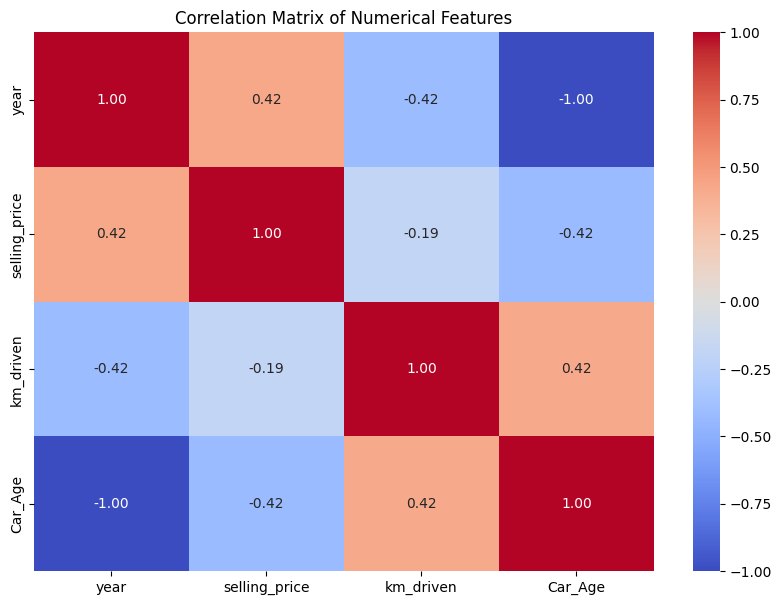

In [119]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Correlation Analysis

The correlation matrix shows the linear relationship between the numerical features and the target variable, Selling_Price.

Features with stronger positive or negative correlations with Selling_Price may provide more useful information for predicting the resale value of a car.

However, correlation alone does not determine feature importance because Machine Learning models can capture nonlinear relationships and interactions between variables.

In [120]:
price_correlation = (
    correlation_matrix["selling_price"]
    .sort_values(ascending=False)
)

print(price_correlation)

selling_price    1.000000
year             0.424260
km_driven       -0.187359
Car_Age         -0.424260
Name: selling_price, dtype: float64


In [121]:
model_df = df.drop(
    columns=["name", "year"]
)

model_df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,Car_Age,Brand
0,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


In [122]:
print(model_df.columns.tolist())

['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'Car_Age', 'Brand']


In [123]:
X = model_df.drop(columns=["selling_price"])

y = model_df["selling_price"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3577, 7)
Target shape: (3577,)


In [124]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['fuel', 'seller_type', 'transmission', 'owner', 'Brand']

Numerical Features:
['km_driven', 'Car_Age']


In [125]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2861
Testing samples: 716


In [127]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2861, 7)
X_test : (716, 7)
y_train: (2861,)
y_test : (716,)


In [128]:
linear_regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

print("Linear Regression pipeline created!")

Linear Regression pipeline created!


In [129]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created!")

Random Forest pipeline created!


In [130]:
linear_regression_pipeline.fit(
    X_train,
    y_train
)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [131]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [132]:
linear_predictions = linear_regression_pipeline.predict(X_test)

random_forest_predictions = random_forest_pipeline.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [133]:
def evaluate_model(model_name, y_true, predictions):
    mae = mean_absolute_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            predictions
        )
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [134]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)


Linear Regression
----------------------------------------
MAE  : 179641.7681
RMSE : 384722.6984
R²   : 0.5405


In [135]:
random_forest_results = evaluate_model(
    "Random Forest Regressor",
    y_test,
    random_forest_predictions
)


Random Forest Regressor
----------------------------------------
MAE  : 158347.8532
RMSE : 364939.1801
R²   : 0.5866


In [136]:
results_df = pd.DataFrame([
    linear_results,
    random_forest_results
])

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,179641.768085,384722.698405,0.540527
1,Random Forest Regressor,158347.853213,364939.180141,0.586567


In [137]:
best_model_name = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"
]

print("Best Performing Model:", best_model_name)

Best Performing Model: Random Forest Regressor


In [138]:
best_r2 = results_df["R2"].max()

print(f"Best R² Score: {best_r2:.4f}")

Best R² Score: 0.5866


## 🏆 Model Comparison

Two regression models were trained and evaluated:

1. Linear Regression
2. Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

The model with the highest R² score and comparatively lower MAE and RMSE was selected as the best-performing model.

The selected model will be used for the final car price prediction application.

In [139]:
# Get the fitted preprocessing step
fitted_preprocessor = random_forest_pipeline.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 43


In [140]:
rf_model = random_forest_pipeline.named_steps["model"]

feature_importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
42,numerical__Car_Age,0.219955
41,numerical__km_driven,0.134531
7,categorical__transmission_Automatic,0.128837
8,categorical__transmission_Manual,0.121778
1,categorical__fuel_Diesel,0.074507
15,categorical__Brand_Audi,0.046969
3,categorical__fuel_Petrol,0.041926
27,categorical__Brand_Land,0.039498
38,categorical__Brand_Toyota,0.036792
16,categorical__Brand_Bmw,0.014075


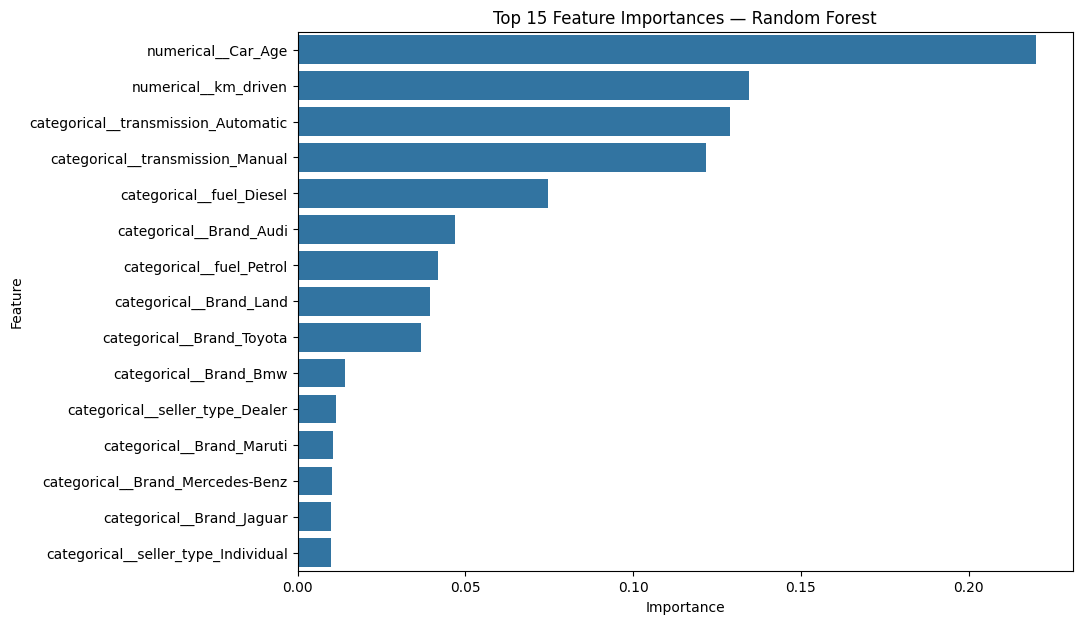

In [141]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance Observation

The Random Forest feature-importance analysis identifies the features that contribute most strongly to predicting used-car selling prices.

The most important features can be examined to understand which vehicle characteristics have the greatest influence on the model's predictions.

One-hot encoded categorical features are represented individually in the feature-importance chart.

In [144]:
best_model_name = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"
]

best_r2 = results_df["R2"].max()

print("Best Model:", best_model_name)
print("Best R² Score:", round(best_r2, 4))

Best Model: Random Forest Regressor
Best R² Score: 0.5866


In [145]:
if best_model_name == "Random Forest Regressor":
    best_model = random_forest_pipeline
else:
    best_model = linear_regression_pipeline

print("Selected model:", best_model_name)

Selected model: Random Forest Regressor


In [146]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/car_price_model.pkl"

joblib.dump(best_model, model_path)

print("Model saved successfully!")
print("Path:", model_path)

Model saved successfully!
Path: ../models/car_price_model.pkl


In [147]:
loaded_model = joblib.load("../models/car_price_model.pkl")

print("car_price_model.pkl loaded successfully!")

car_price_model.pkl loaded successfully!


In [148]:
sample_car = X_test.iloc[[0]]

actual_price = y_test.iloc[0]

predicted_price = loaded_model.predict(sample_car)[0]

print("Actual Selling Price   :", round(actual_price, 2))
print("Predicted Selling Price:", round(predicted_price, 2))

Actual Selling Price   : 270000
Predicted Selling Price: 579652.04


In [149]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": loaded_model.predict(X_test)
})

comparison_df.head(10)

,Actual Price,Predicted Price
0,270000,5.796520e+05
1,525000,4.715419e+05
2,990000,1.493640e+06
3,3800000,2.590276e+06
4,229999,2.420411e+05
5,325000,3.482423e+05
6,210000,1.875000e+05
7,500000,6.678656e+05
8,790000,8.859566e+05
9,360000,4.725367e+05


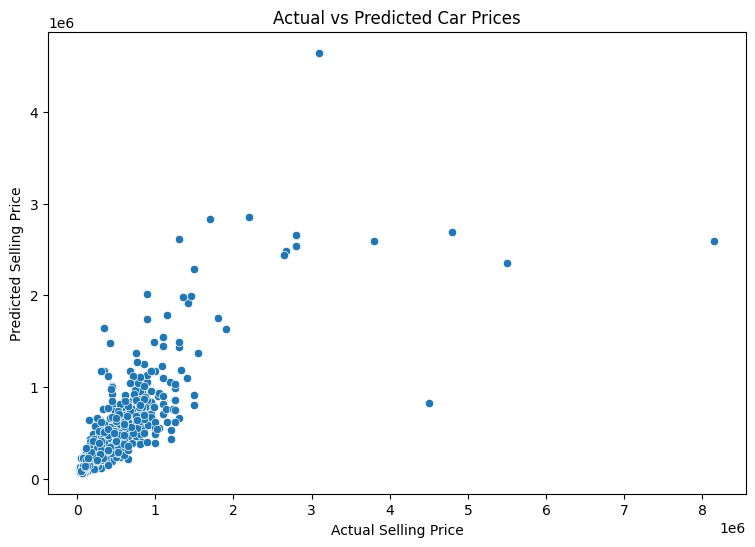

In [150]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=comparison_df,
    x="Actual Price",
    y="Predicted Price"
)

plt.title("Actual vs Predicted Car Prices")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.show()

## Conclusion

The Car Price Prediction project successfully developed regression models to predict the selling price of used cars.

Two machine learning models were trained and evaluated:

- Linear Regression
- Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the highest R² score was selected as the final model and saved as `car_price_model.pkl`.

The feature-importance analysis also helped identify which vehicle characteristics contributed most to the Random Forest model's predictions.

The trained model is ready to be integrated with the Flask backend and Streamlit frontend for the full-stack application.